# Lab 4.1 - Exercise 4: ImageNet-style Classification (Basic CNN vs VGG vs ResNet)

**Student**: 22521609 - Pham Duy Tuan

Muc tieu:
- Xay dung he thong phan loai anh theo cau truc du lieu ImageNet-style.
- Thu nghiem 3 mo hinh: Basic CNN, VGG, ResNet.
- Danh gia va so sanh Accuracy/Loss theo epoch.

> Luu y: Bai nay yeu cau du lieu theo folder `train/` va `val/` (hoac `test/`) trong `DATA_ROOT`.

In [3]:
import os
import gc
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

print('Torch version:', torch.__version__)

Torch version: 2.5.1+cu121


In [4]:
# Hyperparameters (safe defaults to avoid kernel crash)
BATCH_SIZE = 16
LR = 1e-3
EPOCHS = 3
RANDOM_SEED = 42
IMG_SIZE = 160

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = device.type == 'cuda'
print('Device:', device)
print('AMP enabled:', USE_AMP)

Device: cuda
AMP enabled: True


In [5]:
# Data source configuration
# Priority:
# 1) ImageFolder style: DATA_ROOT/train + DATA_ROOT/val(or test)
# 2) Fallback to CIFAR10 if folders are not found
DATA_ROOT = './imagenet_like_data'
USE_IMAGEFOLDER = False

train_dir = os.path.join(DATA_ROOT, 'train')
val_dir = os.path.join(DATA_ROOT, 'val')
if not os.path.isdir(val_dir):
    val_dir = os.path.join(DATA_ROOT, 'test')

if os.path.isdir(train_dir) and os.path.isdir(val_dir):
    USE_IMAGEFOLDER = True
    print('Using ImageFolder dataset')
    print('Train dir:', train_dir)
    print('Val/Test dir:', val_dir)
else:
    print('ImageFolder data not found -> fallback to CIFAR10 dataset')
    print('Expected train dir:', train_dir)
    print('Expected val/test dir:', val_dir)

ImageFolder data not found -> fallback to CIFAR10 dataset
Expected train dir: ./imagenet_like_data\train
Expected val/test dir: ./imagenet_like_data\test


In [6]:
# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

if USE_IMAGEFOLDER:
    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
else:
    # Fallback to CIFAR10 to keep the training pipeline runnable
    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    val_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda'),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == 'cuda'),
)

if hasattr(train_dataset, 'classes'):
    class_names = train_dataset.classes
else:
    class_names = [str(i) for i in range(10)]

num_classes = len(class_names)

print('Train size:', len(train_dataset))
print('Val size  :', len(val_dataset))
print('Num classes:', num_classes)
print('Classes    :', class_names[:10], '...' if len(class_names) > 10 else '')

Files already downloaded and verified


c:\Users\phamt\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Train size: 50000
Val size  : 10000
Num classes: 10
Classes    : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] 


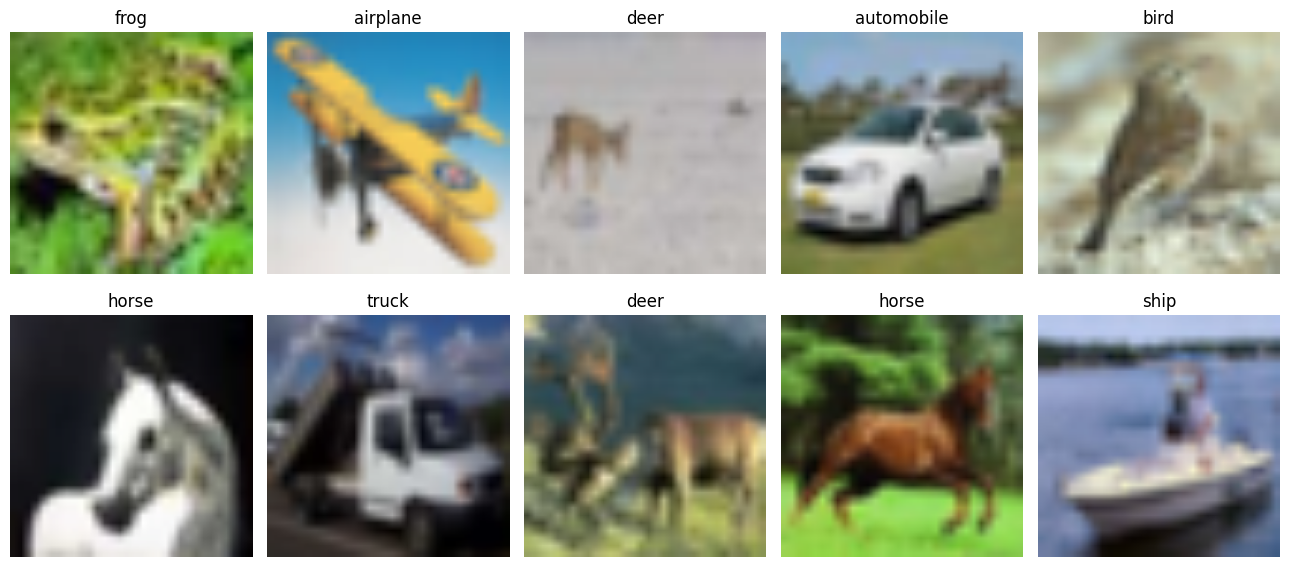

In [7]:
# Visualize some training images (denormalized)
images, labels = next(iter(train_loader))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(images):
        break
    img = images[i].permute(1, 2, 0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_vgg(num_classes, freeze_backbone=True):
    model = models.vgg16(weights=None)
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def build_resnet(num_classes, freeze_backbone=True):
    model = models.resnet18(weights=None)
    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith('fc.'):
                p.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        use_amp = scaler is not None
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device, scaler=None):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    use_amp = scaler is not None
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


def run_training(model, model_name, train_loader, val_loader, device, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda' and USE_AMP))

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    best_acc = 0.0
    best_state = None

    print(f'\nTraining {model_name}...')
    print('Trainable parameters:', sum(p.numel() for p in trainable_params))

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler=scaler)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device, scaler=scaler)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_acc:
            best_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f'Epoch {epoch:02d}/{epochs} | '
            f'Train loss: {tr_loss:.4f}, acc: {tr_acc:.4f} | '
            f'Val loss: {va_loss:.4f}, acc: {va_acc:.4f}'
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [10]:
# We train models one-by-one to avoid GPU memory accumulation
print('Will initialize each model right before training.')

Will initialize each model right before training.


In [11]:
# Train Basic CNN
basic_cnn = BasicCNN(num_classes).to(device)
history_basic = run_training(
    basic_cnn,
    model_name='Basic CNN',
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)

# Free memory before next model
del basic_cnn
if device.type == 'cuda':
    torch.cuda.empty_cache()
gc.collect()


Training Basic CNN...
Trainable parameters: 128842


C:\Users\phamt\AppData\Local\Temp\ipykernel_20600\1769988265.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda' and USE_AMP))
C:\Users\phamt\AppData\Local\Temp\ipykernel_20600\1769988265.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\phamt\AppData\Local\Temp\ipykernel_20600\1769988265.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/3 | Train loss: 1.8149, acc: 0.3210 | Val loss: 1.5880, acc: 0.4076
Epoch 02/3 | Train loss: 1.4786, acc: 0.4608 | Val loss: 1.3663, acc: 0.5071
Epoch 03/3 | Train loss: 1.3210, acc: 0.5185 | Val loss: 1.2169, acc: 0.5568


15

In [12]:
# Train VGG16 (frozen backbone for memory safety)
vgg_model = build_vgg(num_classes, freeze_backbone=True).to(device)
history_vgg = run_training(
    vgg_model,
    model_name='VGG16 (frozen backbone)',
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)

del vgg_model
if device.type == 'cuda':
    torch.cuda.empty_cache()
gc.collect()

C:\Users\phamt\AppData\Local\Temp\ipykernel_20600\1769988265.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda' and USE_AMP))
C:\Users\phamt\AppData\Local\Temp\ipykernel_20600\1769988265.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Training VGG16 (frozen backbone)...
Trainable parameters: 119586826


C:\Users\phamt\AppData\Local\Temp\ipykernel_20600\1769988265.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/3 | Train loss: 2.3148, acc: 0.1056 | Val loss: 2.3033, acc: 0.1000
Epoch 02/3 | Train loss: 2.3047, acc: 0.1002 | Val loss: 2.3025, acc: 0.1000
Epoch 03/3 | Train loss: 2.3048, acc: 0.0982 | Val loss: 2.3027, acc: 0.1000


0

In [13]:
# Train ResNet18 (frozen backbone for memory safety)
resnet_model = build_resnet(num_classes, freeze_backbone=True).to(device)
history_resnet = run_training(
    resnet_model,
    model_name='ResNet18 (frozen backbone)',
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)

del resnet_model
if device.type == 'cuda':
    torch.cuda.empty_cache()
gc.collect()


Training ResNet18 (frozen backbone)...
Trainable parameters: 5130


C:\Users\phamt\AppData\Local\Temp\ipykernel_20600\1769988265.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda' and USE_AMP))
C:\Users\phamt\AppData\Local\Temp\ipykernel_20600\1769988265.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\phamt\AppData\Local\Temp\ipykernel_20600\1769988265.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/3 | Train loss: 2.0170, acc: 0.2568 | Val loss: 1.8549, acc: 0.3167
Epoch 02/3 | Train loss: 1.8814, acc: 0.3154 | Val loss: 1.8023, acc: 0.3267
Epoch 03/3 | Train loss: 1.8426, acc: 0.3320 | Val loss: 1.7895, acc: 0.3497


0

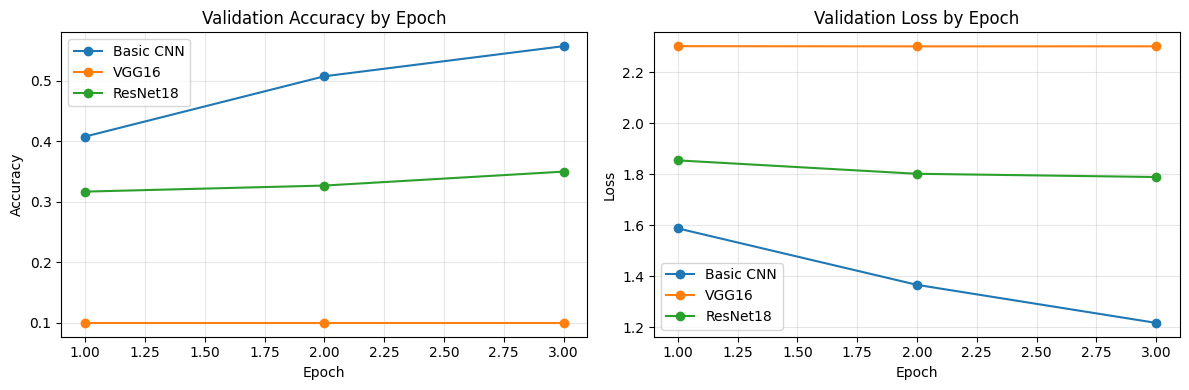

In [14]:
# Compare validation curves
epoch_axis = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epoch_axis, history_basic['val_acc'], marker='o', label='Basic CNN')
axes[0].plot(epoch_axis, history_vgg['val_acc'], marker='o', label='VGG16')
axes[0].plot(epoch_axis, history_resnet['val_acc'], marker='o', label='ResNet18')
axes[0].set_title('Validation Accuracy by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epoch_axis, history_basic['val_loss'], marker='o', label='Basic CNN')
axes[1].plot(epoch_axis, history_vgg['val_loss'], marker='o', label='VGG16')
axes[1].plot(epoch_axis, history_resnet['val_loss'], marker='o', label='ResNet18')
axes[1].set_title('Validation Loss by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# Final summary
final_results = {
    'Basic CNN': {
        'val_acc': history_basic['val_acc'][-1],
        'val_loss': history_basic['val_loss'][-1],
    },
    'VGG16': {
        'val_acc': history_vgg['val_acc'][-1],
        'val_loss': history_vgg['val_loss'][-1],
    },
    'ResNet18': {
        'val_acc': history_resnet['val_acc'][-1],
        'val_loss': history_resnet['val_loss'][-1],
    },
}

print('Final validation results:')
for name, vals in final_results.items():
    print(f"  {name:10s} | acc: {vals['val_acc']:.4f} | loss: {vals['val_loss']:.4f}")

best_model = max(final_results, key=lambda k: final_results[k]['val_acc'])
print(f"\nBest model by final validation accuracy: {best_model}")

Final validation results:
  Basic CNN  | acc: 0.5568 | loss: 1.2169
  VGG16      | acc: 0.1000 | loss: 2.3027
  ResNet18   | acc: 0.3497 | loss: 1.7895

Best model by final validation accuracy: Basic CNN
